In [15]:
import pandas as pd
import numpy as np
from metrics.similarity import WeightedUserSimilarity
import matplotlib.pyplot as plt

In [16]:
TRAIN_PATH = '../data/train.csv'

train_data = pd.read_csv(TRAIN_PATH)

train_data

,user,item,rating
0,1,25715,7.0
1,1,25716,10.0
2,5,25851,9.0
3,6,25923,5.0
4,7,25924,6.0
...,...,...,...
390346,77801,185970,5.0
390347,77801,185971,5.0
390348,77802,44671,10.0
390349,77803,154450,10.0


     n_appearances   count
0                1  120474
1                2   23790
2                3    9127
3                4    4778
4                5    2969
..             ...     ...
175            157       1
176            158       1
177            161       1
178            164       1
179            707       1

[180 rows x 2 columns]


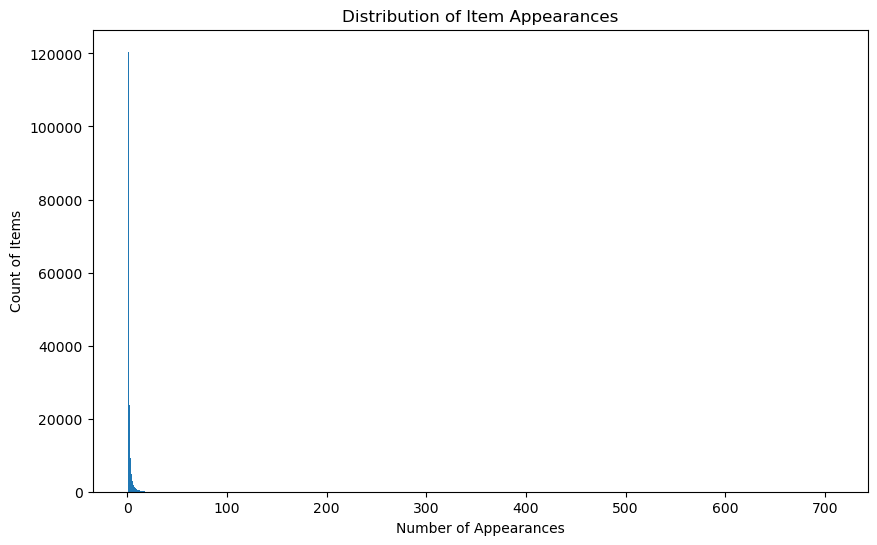

In [18]:
# Count the times each item appears in the dataset
item_counts = train_data['item'].value_counts()

n_appearances = item_counts.value_counts()

n_appearances = n_appearances.rename_axis('n_appearances').reset_index(name='count')

print(n_appearances)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(n_appearances['n_appearances'], n_appearances['count'])
ax.set_xlabel('Number of Appearances')
ax.set_ylabel('Count of Items')
ax.set_title('Distribution of Item Appearances')
plt.show()

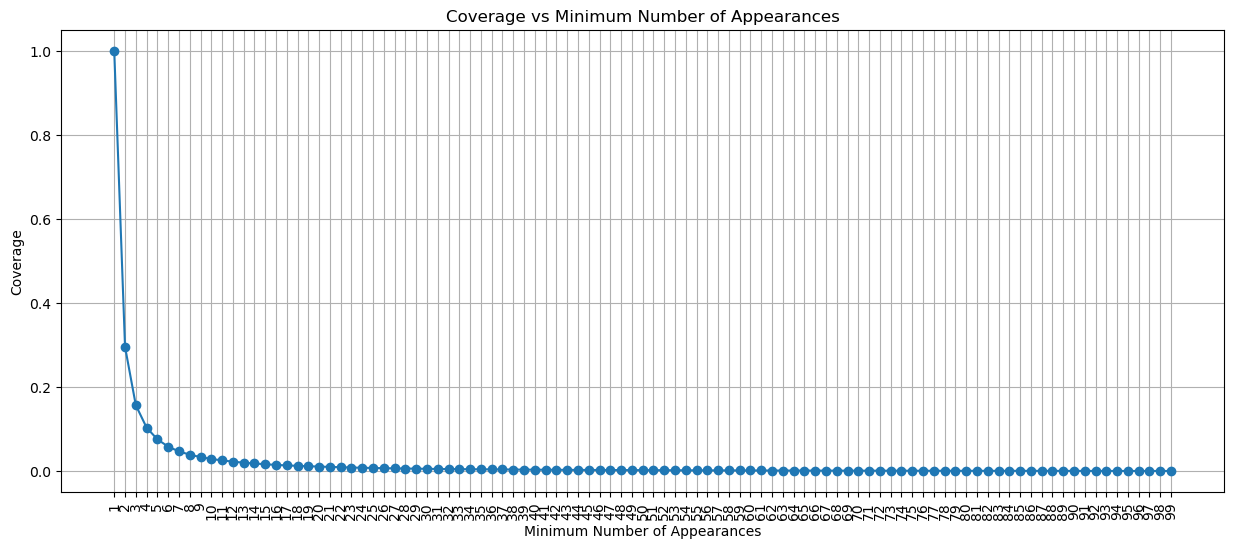

In [24]:
# I want to see the coverage if i only recommend items that appear at least n times
# I will calculate the coverage for different values of n and plot it

total_items = len(item_counts)
coverage = []

for n in range(1, 100):
    items_to_recommend = item_counts[item_counts >= n].index
    coverage.append(len(items_to_recommend) / total_items)

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(range(1, 100), coverage, marker='o')
ax.set_xlabel('Minimum Number of Appearances')
ax.set_ylabel('Coverage')
ax.set_title('Coverage vs Minimum Number of Appearances')
plt.xticks(range(1, 100), rotation=90)
plt.grid()
plt.show()

In [26]:
from metrics.PMF import MatrixFactorization
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(train_data, test_size=0.2, random_state=42)

mf = MatrixFactorization(n_factors=20, n_epochs=50, lr=0.1, reg=0.3)
mf = mf.fit(train_data)

predictions = mf.predict_df(test_data)

predictions

Epoch 001/50 - RMSE train: 1.6983
Epoch 002/50 - RMSE train: 1.4522
Epoch 003/50 - RMSE train: 1.3028
Epoch 004/50 - RMSE train: 1.1687
Epoch 005/50 - RMSE train: 1.0438
Epoch 006/50 - RMSE train: 0.9370
Epoch 007/50 - RMSE train: 0.8531
Epoch 008/50 - RMSE train: 0.7886
Epoch 009/50 - RMSE train: 0.7422
Epoch 010/50 - RMSE train: 0.7073
Epoch 011/50 - RMSE train: 0.6805
Epoch 012/50 - RMSE train: 0.6615
Epoch 013/50 - RMSE train: 0.6459
Epoch 014/50 - RMSE train: 0.6353
Epoch 015/50 - RMSE train: 0.6251
Epoch 016/50 - RMSE train: 0.6182
Epoch 017/50 - RMSE train: 0.6113
Epoch 018/50 - RMSE train: 0.6057
Epoch 019/50 - RMSE train: 0.6017
Epoch 020/50 - RMSE train: 0.5974
Epoch 021/50 - RMSE train: 0.5941
Epoch 022/50 - RMSE train: 0.5906
Epoch 023/50 - RMSE train: 0.5887
Epoch 024/50 - RMSE train: 0.5868
Epoch 025/50 - RMSE train: 0.5835
Epoch 026/50 - RMSE train: 0.5824
Epoch 027/50 - RMSE train: 0.5806
Epoch 028/50 - RMSE train: 0.5784
Epoch 029/50 - RMSE train: 0.5772
Epoch 030/50 -

,user,item,rating,prediction
383547,76197,117697,10.0,8.307252
310482,60143,12984,6.0,5.252247
58005,7238,39395,6.0,7.969261
139500,23504,54067,10.0,7.740051
291645,55721,147272,10.0,7.700105
...,...,...,...,...
188084,33759,41003,10.0,8.465825
330878,64872,164046,4.0,7.254794
130466,21245,43636,7.0,5.588099
294431,56394,148725,3.0,6.209337


Mean Absolute Error: 1.3384


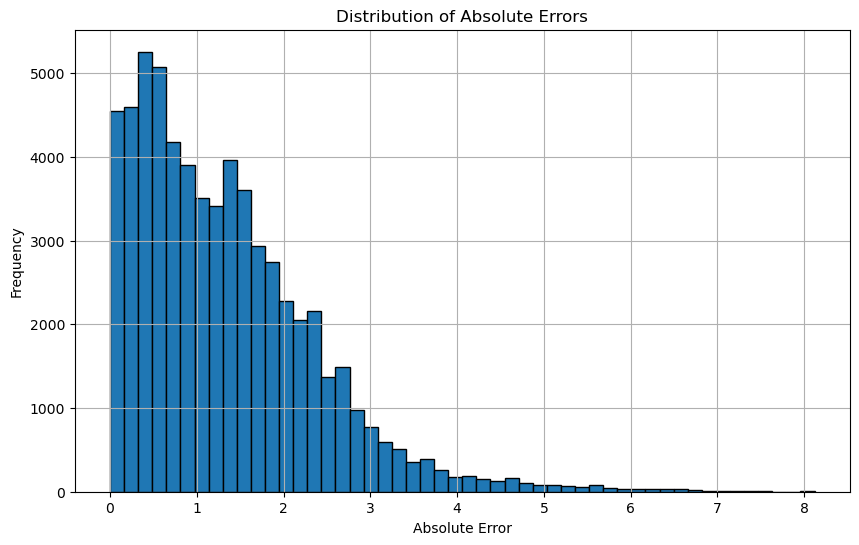

In [28]:
errors = np.abs(predictions['rating'] - predictions['prediction'])

print(f'Mean Absolute Error: {errors.mean():.4f}')
plt.figure(figsize=(10, 6))
plt.hist(errors, bins=50, edgecolor='k')
plt.xlabel('Absolute Error')
plt.ylabel('Frequency')
plt.title('Distribution of Absolute Errors')
plt.grid()